In [31]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from math import pi
import torch.nn as nn
from kornia.losses import total_variation
from monai.losses import DiceLoss, DiceCELoss, SoftclDiceLoss, DiceFocalLoss, NACLLoss
from tqdm import tqdm, tqdm_notebook
from sklearn.metrics import mean_squared_error
from monai.losses.dice import *  # NOQA
from IPython.display import clear_output
from monai import metrics
import monai
from matplotlib import pyplot as plt
import tempfile, os
import copy
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm, tqdm_notebook
import wandb
import random
import torchio as tio
from torchio.data import UniformSampler, Queue


from Models.models import Siren, Finer
from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_data_3d import load_data, get_gt_seg
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images
from LFSynth.ContrastModulation import ContrastModulation
from test3D import visualize_volume_slices

In [80]:
config = copy.deepcopy(default_config)
config["in_features"] = 3
hf_ground_truth, lf_gt, prior_seg_dice, lf_gt_seg_dice, M = load_data(1, config) #uncomment

Device =  mps
torch.Size([87, 96, 192])
BG Noise in different regions : 4.7445857300717 4.415978248235479 4.956849146645869 4.8247938816077935
known_m =  [0.75 0.9  0.9 ]
[[ 28.84998854   0.          -7.89492106]
 [ 28.84998854 -22.35619149   0.        ]
 [  0.          22.35619149  -7.89492106]] [14.53206245  1.51691906 13.01514339]
             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [144.631340676391, 144.63133495698293, 144.631...   
1   [144.63164067639102, 144.63163495701272, 144.6...   
2   [144.632840676391, 144.63283495713193, 144.632...   
3   [144.634340676391, 144.63433495728094, 144.634.

In [93]:
hf_gt_subj = tio.Subject(hf_gt_scalar = tio.ScalarImage(tensor=torch.tensor(torch.from_numpy(norm(hf_ground_truth)).unsqueeze(0), dtype=torch.float32))) #format (C,W,H,D)
patch_size = (44, 48, 48) #W, H, D
# patch_size = (172, 192, 192) #W, H, D
sampler = UniformSampler(patch_size)
# sampler = tio.WeightedSampler(patch_size, probability_map='brain')
subjects_dataset = tio.SubjectsDataset([hf_gt_subj])
queue = Queue(
    subjects_dataset,
    max_length=128,        # max number of items the queue stores
    samples_per_volume=40,
    sampler=sampler,
    num_workers=2,                      # change as needed
)

loader = DataLoader(queue, batch_size=1)
# for idx, patch in enumerate(loader):
    # print(idx, patch["hf_gt_scalar"][tio.DATA].shape)
    # fig = visualize_volume_slices(patch["hf_gt_scalar"][tio.DATA].squeeze(0).squeeze(0), patch["hf_gt_scalar"][tio.DATA].squeeze(0).squeeze(0), axis=0, num_slices=5, title1='gt', title2='seg_gt')
    # plt.show()
    # fig.savefig('/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/temp_patches/'+ str(idx) + '.png')


In [94]:
def make_patch_coords(pw, ph, pd, device):
    # local coords in [-1, 1] over patch grid
    z = torch.linspace(-1.0, 1.0, pd, device=device)
    y = torch.linspace(-1.0, 1.0, ph, device=device)
    x = torch.linspace(-1.0, 1.0, pw, device=device)
    zz, yy, xx = torch.meshgrid(z, y, x, indexing='ij')  # shape (pd, ph, pw)
    coords = torch.stack([xx, yy, zz], dim=-1)           # (pd, ph, pw, 3)
    coords = coords.view(-1, 3)                          # (N, 3)
    return coords  # CPU or device tensor

In [95]:
device = get_device()
model = get_model(config).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2.5e-4)
loss_fn = nn.MSELoss()
pw, ph, pd = patch_size
coords_patch = make_patch_coords(pw, ph, pd, device=device)  # (N, 3)
N = coords_patch.shape[0]
B = 1 #batch_size
epochs = 3

Device =  mps


In [96]:
temp = next(iter(loader))
temp["hf_gt_scalar"][tio.DATA].view(1, 1, -1).permute(0,2,1).shape

torch.Size([1, 101376, 1])

In [97]:
chunk_size = patch_size
for epoch in range(epochs):
    running_loss = 0.0
    n_batches = 0
    for idx, batch in enumerate(loader):
        # batch is a dict; images accessible as batch['low'][tio.DATA] and batch['high'][tio.DATA]

        # low_patches = batch['low'][tio.DATA].to(device)   # (B,1,pw,ph,pd)
        high_patches = batch["hf_gt_scalar"][tio.DATA].to(device) # (B,1,pw,ph,pd)

        # B = low_patches.shape[0]
        hf_target = high_patches.view(B, 1, -1).permute(0,2,1)  # (B,*N,1)

        # Make coords batch: (B,N,3)
        coords_batched = coords_patch.unsqueeze(0).expand(B, -1, -1)  # (B,*N,3)

        optimizer.zero_grad()
        # preds = model(coords_batched)  # (B,N,1)
        model_output_seg_pre, model_output_seg, model_output_img_pre , model_output_img, coords = model(coords_batched)
                
        model_output_img_dice = torch.stack((model_output_img[:,:,3].reshape(chunk_size), model_output_img[:,:,0].reshape(chunk_size), model_output_img[:,:,1].reshape(chunk_size), model_output_img[:,:,2].reshape(chunk_size)), dim=0).unsqueeze(0)
        hf_pred = model_output_img_dice[0,0] + model_output_img_dice[0,1] + model_output_img_dice[0,2] #+ model_output_img_dice[0,3]
        
        loss = loss_fn(hf_pred.flatten(), hf_target.flatten())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    epoch_loss = running_loss / max(1, n_batches)
    if (epoch+1) % max(1, epochs//10) == 0 or epoch==0:
        print(f"Epoch {epoch+1}/{epochs}  loss: {epoch_loss:.6f}")

Epoch 1/3  loss: 0.056347
Epoch 2/3  loss: 0.053006
Epoch 3/3  loss: 0.050697


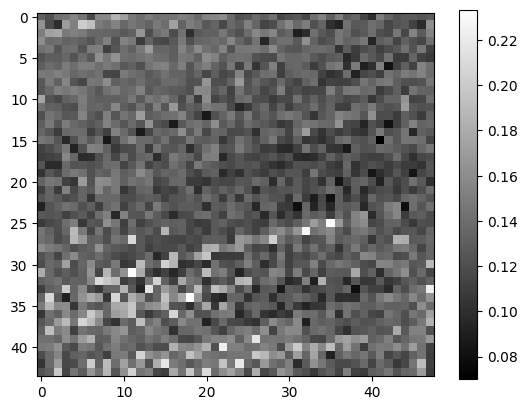

In [98]:
plt.imshow(hf_pred.view(44,48,48)[:,:,22].detach().cpu(),cmap='gray')
plt.colorbar()